# Vehicle Clustering

Estimated time needed: **60** minutes
Due Date : 14th June 2026


## Objectives

After completing this lab you will be able to:

*   Use scikit-learn to do Hierarchical and K-Means
*   Create dendograms to visualize the clustering
*   Perform parameter tuning to obtain the best clustering results for both algorithms

<hr>
<h1 id="clustering_vehicle_dataset">Clustering on Vehicle dataset</h1>

Imagine that an automobile manufacturer has developed prototypes for a new vehicle. Before introducing the new model into its range, the manufacturer wants to determine which existing vehicles on the market are most like the prototypes--that is, how vehicles can be grouped, which group is the most similar with the model, and therefore which models they will be competing against.

Our objective here, is to use clustering methods, to find the most distinctive clusters of vehicles. It will summarize the existing vehicles and help manufacturers to make decision about the supply of new models.

<h1 id="hierarchical_agglomerative">Hierarchical Clustering - Agglomerative</h1>

We will be looking at a clustering technique, which is <b>Agglomerative Hierarchical Clustering</b>. Remember that agglomerative is the bottom up approach. <br> <br>
In this lab, we will be looking at Agglomerative clustering, which is more popular than Divisive clustering. <br> <br>
We will also be using Complete Linkage as the Linkage Criteria. <br> <b> <i> NOTE: You can also try using Average Linkage wherever Complete Linkage would be used to see the difference! </i> </b>

# Import all the libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Read data

Let's read dataset to see what features the manufacturer has collected about the existing models.

In [3]:
# Upload dataset to Google Colab
# Upload file here
from google.colab import files
uploaded = files.upload()


Saving cars.csv to cars.csv


# Perform simple data exploration here

In [4]:
df = pd.read_csv('cars.csv')

# Display first 5 records
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0,21.50,1.8,140,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0
1,Acura,TL,39.384,19.875,0,28.40,3.2,225,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0
2,Acura,CL,14.114,18.225,0,33.95,3.2,225,106.9,70.6,192.0,3.470,17.2,26.0,2.647,0
3,Acura,RL,8.588,29.725,0,42.00,3.5,210,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0
4,Audi,A4,20.397,22.255,0,23.99,1.8,150,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0


In [5]:
# Dataset information
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   manufact   156 non-null    object 
 1   model      156 non-null    object 
 2   sales      156 non-null    float64
 3   resale     156 non-null    float64
 4   type       156 non-null    int64  
 5   price      156 non-null    float64
 6   engine_s   156 non-null    float64
 7   horsepow   156 non-null    int64  
 8   wheelbas   156 non-null    float64
 9   width      156 non-null    float64
 10  length     156 non-null    float64
 11  curb_wgt   156 non-null    float64
 12  fuel_cap   156 non-null    float64
 13  mpg        156 non-null    float64
 14  lnsales    156 non-null    float64
 15  partition  156 non-null    int64  
dtypes: float64(11), int64(3), object(2)
memory usage: 19.6+ KB


,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.0
mean,52.994987,17.368519,0.256410,27.432801,3.060897,185.948718,107.487179,71.150000,187.343590,3.380538,17.951923,23.800641,3.291468,0.0
std,68.248508,10.784874,0.438057,14.314919,1.044653,56.700321,7.641303,3.451872,13.431754,0.629248,3.887921,4.281129,1.321317,0.0
min,0.110000,0.900000,0.000000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,-2.207000,0.0
25%,14.035000,10.970000,0.000000,18.081250,2.300000,149.500000,103.000000,68.400000,177.575000,2.973000,15.800000,21.000000,2.641500,0.0
50%,29.213000,14.095000,0.000000,23.099500,3.000000,177.500000,107.000000,70.550000,187.900000,3.355000,17.200000,24.000000,3.374500,0.0
75%,68.069750,19.878750,1.000000,32.253750,3.575000,215.000000,112.200000,73.425000,196.125000,3.788750,19.575000,26.000000,4.220750,0.0
max,540.561000,58.600000,1.000000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,6.293000,0.0


### Feature selection

Let's select our feature set.

Use only engine, horsepower, wheelbase, width, length, curb weight, fuel capacity and mpg as variable for clustering purpose

In [6]:
X = df[['engine_s',
        'horsepow',
        'wheelbas',
        'width',
        'length',
        'curb_wgt',
        'fuel_cap',
        'mpg']]

print(X.shape)
X.head()

(156, 8)


,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg
0,1.8,140,101.2,67.3,172.4,2.639,13.2,28.0
1,3.2,225,108.1,70.3,192.9,3.517,17.2,25.0
2,3.2,225,106.9,70.6,192.0,3.470,17.2,26.0
3,3.5,210,114.6,71.4,196.6,3.850,18.0,22.0
4,1.8,150,102.6,68.2,178.0,2.998,16.4,27.0


### Normalization

Now we can normalize the feature set. **MinMaxScaler** transforms features by scaling each feature to a given range. It is by default (0, 1). That is, this estimator scales and translates each feature individually such that it is between zero and one.


In [7]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[0.11428571, 0.21518987, 0.18655098, 0.2716763 , 0.30625832,
        0.20233886, 0.13364055, 0.43333333],
       [0.31428571, 0.43037975, 0.3362256 , 0.44508671, 0.5792277 ,
        0.44112048, 0.31797235, 0.33333333],
       [0.31428571, 0.43037975, 0.31019523, 0.46242775, 0.56724368,
        0.42833832, 0.31797235, 0.36666667],
       [0.35714286, 0.39240506, 0.47722343, 0.50867052, 0.62849534,
        0.53168344, 0.35483871, 0.23333333],
       [0.11428571, 0.24050633, 0.21691974, 0.32369942, 0.38082557,
        0.2999728 , 0.28110599, 0.4       ]])

### Plot Dendogram

Now, we can use the 'AgglomerativeClustering' function from scikit-learn library to cluster the dataset. The AgglomerativeClustering performs a hierarchical clustering using a bottom up approach. The linkage criteria determines the metric used for the merge strategy:

*   Ward minimizes the sum of squared differences within all clusters. It is a variance-minimizing approach and in this sense is similar to the k-means objective function but tackled with an agglomerative hierarchical approach.
*   Maximum or complete linkage minimizes the maximum distance between observations of pairs of clusters.
*   Average linkage minimizes the average of the distances between all observations of pairs of clusters.

<b>You can explore different type of linkage as well</b>

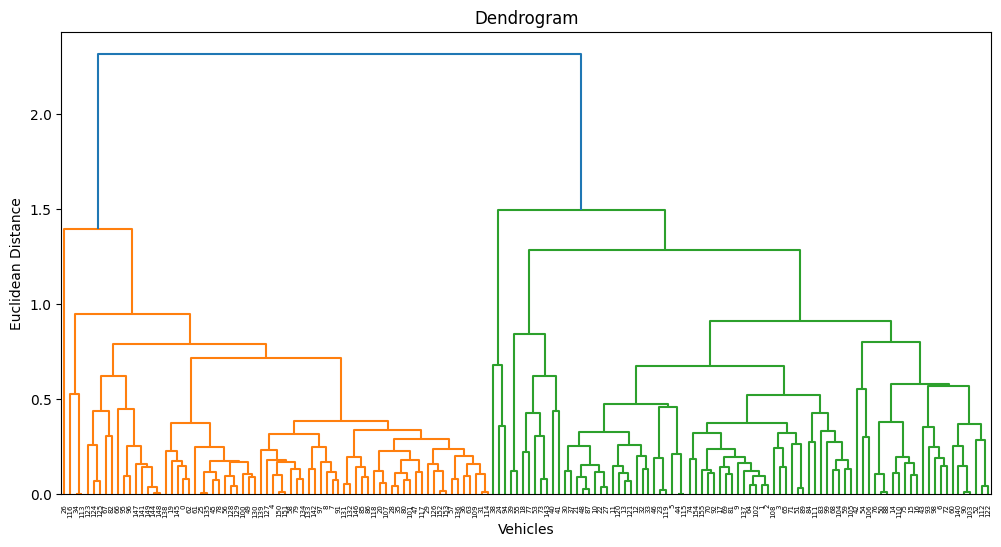

In [8]:
# Create a dendrogram
plt.figure(figsize=(12,6))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled,
                method='complete')
)

plt.title('Dendrogram')
plt.xlabel('Vehicles')
plt.ylabel('Euclidean Distance')

plt.show()

# Fitting the Model and Predicting Clusters

<b> 1st Step </b>
Setting the Number of Clusters

<b> 2nd Step </b>
Creating the Agglomerative Clustering Model

<b> 3rd Step</b>
Fit and Predict the cluster


In [9]:
# Create Agglomerative Clustering model
agglom = AgglomerativeClustering(
    n_clusters=2,
    linkage='complete'
)

# Fit the model and predict clusters
y_agglom = agglom.fit_predict(X_scaled)

# Show cluster labels
y_agglom

array([1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0])

In [12]:
#to add the cluster result into the dataset
df['Cluster'] = y_agglom

df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition,Cluster
0,Acura,Integra,16.919,16.360,0,21.50,1.8,140,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0,1
1,Acura,TL,39.384,19.875,0,28.40,3.2,225,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0,0
2,Acura,CL,14.114,18.225,0,33.95,3.2,225,106.9,70.6,192.0,3.470,17.2,26.0,2.647,0,0
3,Acura,RL,8.588,29.725,0,42.00,3.5,210,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0,0
4,Audi,A4,20.397,22.255,0,23.99,1.8,150,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0,1


# Silhouette Score

In [13]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_agglom)

print("Silhouette Score:", score)

Silhouette Score: 0.3636769387189013


<br> <b> <i>You can also try using different type of linkage and cluster to see the difference! </i> </b>
<br> Once done, write your findings

In [15]:
#A higher silhouette score indicates better-separated and more cohesive clusters.
for n in range(2,6):
    model = AgglomerativeClustering(
        n_clusters=n,
        linkage='complete'
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print("Clusters:", n, "Silhouette Score:", round(score,4))

Clusters: 2 Silhouette Score: 0.3637
Clusters: 3 Silhouette Score: 0.3443
Clusters: 4 Silhouette Score: 0.3287
Clusters: 5 Silhouette Score: 0.3432


# Findings for Hierarchical Clustering





In [19]:
print("""
Hierarchical Clustering was successfully applied to the vehicle dataset \n
using Agglomerative Clustering with Complete Linkage. The model achieved a \n
silhouette score of approximately 0.3637, indicating a moderate clustering structure. \n
Vehicles within the same cluster share similar characteristics such as engine size, \n
horsepower, fuel capacity, vehicle dimensions, and fuel efficiency. The clustering \n
process successfully grouped similar vehicles together and provided meaningful \n
insights into different vehicle categories. Overall, the clustering result is \n
acceptable for exploratory analysis and vehicle segmentation.
""")


Hierarchical Clustering was successfully applied to the vehicle dataset 

using Agglomerative Clustering with Complete Linkage. The model achieved a 

silhouette score of approximately 0.3637, indicating a moderate clustering structure. 

Vehicles within the same cluster share similar characteristics such as engine size, 

horsepower, fuel capacity, vehicle dimensions, and fuel efficiency. The clustering 

process successfully grouped similar vehicles together and provided meaningful 

insights into different vehicle categories. Overall, the clustering result is 

acceptable for exploratory analysis and vehicle segmentation.



# KMeans

Replicate the task for K Means Algorithms

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Create KMeans model
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Fit and predict clusters
y_kmeans = kmeans.fit_predict(X_scaled)

# Calculate silhouette score
kmeans_score = silhouette_score(X_scaled, y_kmeans)

print("KMeans Silhouette Score:", kmeans_score)

KMeans Silhouette Score: 0.366574600139456


# FIndings for K-Means Clustering

In [21]:
print("""
K-Means clustering was performed effectively to the car dataset with two clusters. \n
The model has a silhouette score of around 0.37, indicating a substantial clustering \n
structure. Vehicles were categorized according to engine size, horsepower, dimensions, \n
weight, fuel capacity, and fuel economy. The clustering findings demonstrated that \n
K-Means could construct compact and well-separated groups of cars, making it appropriate \n
for vehicle segmentation and exploratory analysis.
""")


K-Means clustering was performed effectively to the car dataset with two clusters. 

The model has a silhouette score of around 0.37, indicating a substantial clustering 

structure. Vehicles were categorized according to engine size, horsepower, dimensions, 

weight, fuel capacity, and fuel economy. The clustering findings demonstrated that 

K-Means could construct compact and well-separated groups of cars, making it appropriate 

for vehicle segmentation and exploratory analysis.



# Conclusion and Key Takeway

In [22]:
print("""
Conclusion:

Both Hierarchical Clustering and K-Means were successful in classifying automobiles \n
based on their technical parameters. When the silhouette scores were compared, K-Means \n
beat Hierarchical Clustering marginally, resulting in more compact and well-separated \n
clusters. Overall, clustering gives useful insights on vehicle segmentation and can \n
help the automobile sector make data-driven decisions.
""")


Conclusion:

Both Hierarchical Clustering and K-Means were successful in classifying automobiles 

based on their technical parameters. When the silhouette scores were compared, K-Means 

beat Hierarchical Clustering marginally, resulting in more compact and well-separated 

clusters. Overall, clustering gives useful insights on vehicle segmentation and can 

help the automobile sector make data-driven decisions.

